#  Preparación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
cal = pd.read_excel("DIM_CALENDAR (2).xlsx")
cat = pd.read_csv("DIM_CATEGORY (2).csv")
prod = pd.read_excel("DIM_PRODUCT (1).xlsx")
seg = pd.read_excel("DIM_SEGMENT (1).xlsx")
sales = pd.read_csv("FACT_SALES (1).csv")
print("DIM_CALENDAR:", cal.shape)
print("DIM_CATEGORY:", cat.shape)
print("DIM_PRODUCT:", prod.shape)
print("DIM_SEGMENT:", seg.shape)
print("FACT_SALES:", sales.shape)
display(cal.head())
display(cat.head())
display(prod.head())
display(seg.head())
display(sales.head())

DIM_CALENDAR: (156, 5)
DIM_CATEGORY: (5, 2)
DIM_PRODUCT: (505, 9)
DIM_SEGMENT: (53, 6)
FACT_SALES: (122002, 6)


,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07


,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


,CATEGORY,ATTR1,ATTR2,ATTR3,FORMAT,SEGMENT
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH
3,1,CLORO,CLORO,MULTIUSOS,GEL,BLEACH
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.01,0.14,1.00,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.49,116.52,2.92,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.39,68.45,5.17,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.02,1.48,1.83,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.04,182.84,5.38,TOTAL AUTOS AREA 5


In [2]:
dfs = {"cal": cal,"cat": cat,"prod": prod,"seg": seg,"sales": sales}
for name, df in dfs.items():
    print(df.isnull().sum())
    print("\nDuplicados:", df.duplicated().sum())

WEEK           0
YEAR           0
MONTH          0
WEEK_NUMBER    0
DATE           0
dtype: int64

Duplicados: 0
ID_CATEGORY    0
CATEGORY       0
dtype: int64

Duplicados: 0
MANUFACTURER        0
BRAND               0
ITEM                2
ITEM_DESCRIPTION    0
CATEGORY            0
FORMAT              0
ATTR1               6
ATTR2               0
ATTR3               6
dtype: int64

Duplicados: 0
CATEGORY    0
ATTR1       0
ATTR2       0
ATTR3       1
FORMAT      0
SEGMENT     0
dtype: int64

Duplicados: 0
WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
dtype: int64

Duplicados: 0


In [3]:
for df in dfs.values():
    df.columns = df.columns.str.strip().str.upper()
def limpiar_texto(columna):
    return (columna.astype(str).str.strip().str.upper().str.replace(r"\s+", " ", regex=True))

In [4]:
columnas_texto_prod = ["MANUFACTURER", "BRAND", "ITEM", "ITEM_DESCRIPTION", "FORMAT", "ATTR1", "ATTR2", "ATTR3"]
columnas_texto_seg = ["FORMAT", "ATTR1", "ATTR2", "ATTR3", "SEGMENT"]
columnas_texto_sales = ["ITEM_CODE", "REGION"]
columnas_texto_cat = ["CATEGORY"]
for col in columnas_texto_prod:
    prod[col] = limpiar_texto(prod[col])
for col in columnas_texto_seg:
    seg[col] = limpiar_texto(seg[col])
for col in columnas_texto_sales:
    sales[col] = limpiar_texto(sales[col])
for col in columnas_texto_cat:
    cat[col] = limpiar_texto(cat[col])

In [5]:
prod["ITEM_KEY"] = prod["ITEM"].astype(str).str.strip().str.lstrip("0")
sales["ITEM_KEY"] = sales["ITEM_CODE"].astype(str).str.strip().str.lstrip("0")
prod["CATEGORY"] = prod["CATEGORY"].astype(str).str.strip()
seg["CATEGORY"] = seg["CATEGORY"].astype(str).str.strip()
cat["ID_CATEGORY"] = cat["ID_CATEGORY"].astype(str).str.strip()
cal["WEEK"] = cal["WEEK"].astype(str).str.strip()
sales["WEEK"] = sales["WEEK"].astype(str).str.strip()

# Consolidación

In [6]:
columnas_numericas_sales = ["TOTAL_UNIT_SALES","TOTAL_VALUE_SALES","TOTAL_UNIT_AVG_WEEKLY_SALES"]
for col in columnas_numericas_sales:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

In [7]:
cal["DATE"] = pd.to_datetime(cal["DATE"], errors="coerce")
cal["YEAR"] = pd.to_numeric(cal["YEAR"], errors="coerce")
cal["MONTH"] = pd.to_numeric(cal["MONTH"], errors="coerce")
cal["WEEK_NUMBER"] = pd.to_numeric(cal["WEEK_NUMBER"], errors="coerce")
cal = cal.sort_values("DATE").reset_index(drop=True)
print("Fecha mínima:", cal["DATE"].min())
print("Fecha máxima:", cal["DATE"].max())

Fecha mínima: 2021-01-10 00:00:00
Fecha máxima: 2024-01-01 00:00:00


In [8]:
cal = cal.drop_duplicates(subset=["WEEK"])
cat = cat.drop_duplicates(subset=["ID_CATEGORY"])
prod = prod.drop_duplicates(subset=["ITEM_KEY"])
seg = seg.drop_duplicates(subset=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"])

In [9]:
sales_cal = sales.merge(cal[["WEEK", "YEAR", "MONTH", "WEEK_NUMBER", "DATE"]],on="WEEK",how="left")
sales_cal.shape

(122002, 11)

In [10]:
sales_prod = sales_cal.merge(prod,on="ITEM_KEY",how="left")
sales_prod.shape

(122002, 20)

In [11]:
sales_prod_cat = sales_prod.merge(cat,left_on="CATEGORY",right_on="ID_CATEGORY",how="left",suffixes=("", "_CATEGORY_NAME"))
sales_prod_cat.shape

(122002, 22)

In [12]:
sales_prod_cat

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_KEY,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_CATEGORY_NAME
0,34-22,7501058792808BP2,0.01,0.14,1.00,TOTAL AUTOS AREA 5,7501058792808BP2,2022,8,34,2022-08-28,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
1,34-22,7501058715883,0.49,116.52,2.92,TOTAL AUTOS AREA 5,7501058715883,2022,8,34,2022-08-28,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
2,34-22,7702626213774,1.39,68.45,5.17,TOTAL AUTOS AREA 5,7702626213774,2022,8,34,2022-08-28,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
3,34-22,7501058716422,0.02,1.48,1.83,TOTAL AUTOS AREA 5,7501058716422,2022,8,34,2022-08-28,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
4,34-22,7501058784353,2.04,182.84,5.38,TOTAL AUTOS AREA 5,7501058784353,2022,8,34,2022-08-28,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.19,150.83,4.00,TOTAL AUTOS SCANNING MEXICO,7501058792778BP1,2023,7,26,2023-07-03,RECKITT,VANISH,7501058792778BP1,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
121998,26-23,7501058757630,1.95,235.42,2.80,TOTAL AUTOS SCANNING MEXICO,7501058757630,2023,7,26,2023-07-03,RECKITT,VANISH,7501058757630,VANISH PODER O2 PRE-LAVADOR BOT.ATOM. 650 ML N...,1,LIQUIDO,PRELAVADOR,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
121999,26-23,7501058753441,18.01,429.29,9.10,TOTAL AUTOS SCANNING MEXICO,7501058753441,2023,7,26,2023-07-03,RECKITT,VANISH,7501058753441,VANISH PODER O2 DOYPACK 120 GR 7501058753441,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT
122000,26-23,7702626204208BP1,21.15,210.28,22.17,TOTAL AUTOS SCANNING MEXICO,7702626204208BP1,2023,7,26,2023-07-03,RECKITT,VANISH,7702626204208BP1,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT


In [13]:
consolidated_df = sales_prod_cat.merge(seg,on=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"],how="left")
consolidated_df.shape

(122002, 23)

In [14]:
consolidated_df.isnull().sum().sort_values(ascending=False).head(20)

WEEK                           0
ITEM_CODE                      0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
ITEM_KEY                       0
YEAR                           0
MONTH                          0
WEEK_NUMBER                    0
DATE                           0
MANUFACTURER                   0
BRAND                          0
ITEM                           0
ITEM_DESCRIPTION               0
CATEGORY                       0
FORMAT                         0
ATTR1                          0
ATTR2                          0
ATTR3                          0
dtype: int64

In [15]:
print("Registros sin fecha:", consolidated_df["DATE"].isnull().sum())
print("Registros sin producto:", consolidated_df["ITEM_DESCRIPTION"].isnull().sum())
print("Registros sin categoría:", consolidated_df["CATEGORY_CATEGORY_NAME"].isnull().sum())
print("Registros sin segmento:", consolidated_df["SEGMENT"].isnull().sum())

Registros sin fecha: 0
Registros sin producto: 0
Registros sin categoría: 0
Registros sin segmento: 0


In [16]:
match_producto = consolidated_df["ITEM_DESCRIPTION"].notnull().mean() * 100
match_categoria = consolidated_df["CATEGORY_CATEGORY_NAME"].notnull().mean() * 100
match_segmento = consolidated_df["SEGMENT"].notnull().mean() * 100
print(f"Match producto: {match_producto:.2f}%")
print(f"Match categoría: {match_categoria:.2f}%")
print(f"Match segmento: {match_segmento:.2f}%")

Match producto: 100.00%
Match categoría: 100.00%
Match segmento: 100.00%


In [17]:
consolidated_df = consolidated_df.rename(columns={"CATEGORY_CATEGORY_NAME": "CATEGORY_NAME"})
consolidated_df = consolidated_df[consolidated_df["TOTAL_VALUE_SALES"].notnull()].copy()
consolidated_df.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_KEY,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_NAME,SEGMENT
0,34-22,7501058792808BP2,0.01,0.14,1.00,TOTAL AUTOS AREA 5,7501058792808BP2,2022,8,34,2022-08-28,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
1,34-22,7501058715883,0.49,116.52,2.92,TOTAL AUTOS AREA 5,7501058715883,2022,8,34,2022-08-28,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
2,34-22,7702626213774,1.39,68.45,5.17,TOTAL AUTOS AREA 5,7702626213774,2022,8,34,2022-08-28,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
3,34-22,7501058716422,0.02,1.48,1.83,TOTAL AUTOS AREA 5,7501058716422,2022,8,34,2022-08-28,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
4,34-22,7501058784353,2.04,182.84,5.38,TOTAL AUTOS AREA 5,7501058784353,2022,8,34,2022-08-28,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER


In [18]:
consolidated_df[["TOTAL_UNIT_SALES", "TOTAL_VALUE_SALES", "TOTAL_UNIT_AVG_WEEKLY_SALES"]].describe()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
count,"122,002.00","122,002.00","122,002.00"
mean,3.21,90.51,10.10
std,14.50,350.24,22.65
min,0.00,0.00,0.04
25%,0.06,2.66,2.32
50%,0.37,16.81,3.99
75%,1.52,62.96,8.90
max,504.68,"12,236.76",794.00


In [19]:
consolidated_df["REGION"].value_counts()

REGION
TOTAL AUTOS SCANNING MEXICO    20990
TOTAL AUTOS AREA 2             18505
TOTAL AUTOS AREA 4             17182
TOTAL AUTOS AREA 6             16913
TOTAL AUTOS AREA 3             16496
TOTAL AUTOS AREA 5             16135
TOTAL AUTOS AREA 1             15781
Name: count, dtype: int64

In [20]:
areas_df = consolidated_df[consolidated_df["REGION"].str.contains("AREA", na=False)].copy()
mexico_df = consolidated_df[consolidated_df["REGION"] == "TOTAL AUTOS SCANNING MEXICO"].copy()
areas_sum = (areas_df.groupby(["WEEK", "ITEM_CODE"], as_index=False)
    .agg(area_unit_sales=("TOTAL_UNIT_SALES", "sum"),area_value_sales=("TOTAL_VALUE_SALES", "sum")))
mexico_sum = (mexico_df.groupby(["WEEK", "ITEM_CODE"], as_index=False)
    .agg(mexico_unit_sales=("TOTAL_UNIT_SALES", "sum"),mexico_value_sales=("TOTAL_VALUE_SALES", "sum")))
comparacion_mexico_areas = mexico_sum.merge(areas_sum,on=["WEEK", "ITEM_CODE"],how="left")
comparacion_mexico_areas["diff_unit_sales"] = (comparacion_mexico_areas["mexico_unit_sales"]-comparacion_mexico_areas["area_unit_sales"])
comparacion_mexico_areas["diff_value_sales"] = (comparacion_mexico_areas["mexico_value_sales"]-comparacion_mexico_areas["area_value_sales"])
comparacion_mexico_areas[["diff_unit_sales", "diff_value_sales"]].describe()

,diff_unit_sales,diff_value_sales
count,"20,990.00","20,990.00"
mean,-0.00,-0.00
std,0.00,0.00
min,-0.00,-0.00
25%,0.00,-0.00
50%,0.00,0.00
75%,0.00,0.00
max,0.00,0.00


In [21]:
diff_unidades = comparacion_mexico_areas["diff_unit_sales"].sum()
diff_valor = comparacion_mexico_areas["diff_value_sales"].sum()
print("Diferencia total en unidades:", diff_unidades)
print("Diferencia total en valor:", diff_valor)
if abs(diff_unidades) <= 1 and abs(diff_valor) <= 5:
    print("No existen diferencias relevantes entre SCANNING MEXICO y la suma de las áreas.")
else:
    print("Existen diferencias relevantes entre SCANNING MEXICO y la suma de las áreas.")

Diferencia total en unidades: -0.11999999999974602
Diferencia total en valor: -1.2530000000073158
No existen diferencias relevantes entre SCANNING MEXICO y la suma de las áreas.


In [22]:
consolidated_df_areas = consolidated_df[consolidated_df["REGION"] != "TOTAL AUTOS SCANNING MEXICO"].copy()
consolidated_df_mexico = consolidated_df[consolidated_df["REGION"] == "TOTAL AUTOS SCANNING MEXICO"].copy()
print("Base completa:", consolidated_df.shape)
print("Base solo áreas:", consolidated_df_areas.shape)
print("Base total México:", consolidated_df_mexico.shape)

Base completa: (122002, 23)
Base solo áreas: (101012, 23)
Base total México: (20990, 23)


In [23]:
consolidated_df_areas

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_KEY,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_NAME,SEGMENT
0,34-22,7501058792808BP2,0.01,0.14,1.00,TOTAL AUTOS AREA 5,7501058792808BP2,2022,8,34,2022-08-28,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
1,34-22,7501058715883,0.49,116.52,2.92,TOTAL AUTOS AREA 5,7501058715883,2022,8,34,2022-08-28,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
2,34-22,7702626213774,1.39,68.45,5.17,TOTAL AUTOS AREA 5,7702626213774,2022,8,34,2022-08-28,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
3,34-22,7501058716422,0.02,1.48,1.83,TOTAL AUTOS AREA 5,7501058716422,2022,8,34,2022-08-28,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
4,34-22,7501058784353,2.04,182.84,5.38,TOTAL AUTOS AREA 5,7501058784353,2022,8,34,2022-08-28,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT AND SANIT,POWDER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121929,22-23,7501058717276,0.01,1.35,1.00,TOTAL AUTOS AREA 6,7501058717276,2023,6,22,2023-06-05,RECKITT,LYSOL,7501058717276,LYSOL SANITIZANTE DE ROPA SPORT BOTELLA 1.21 L...,1,LIQUIDO,SANITIZANTE,SANITIZANTE,SANITIZANTE,1,FABRIC TREATMENT AND SANIT,SANITIZER
121930,22-23,7501058795908,0.14,23.47,2.09,TOTAL AUTOS AREA 6,7501058795908,2023,6,22,2023-06-05,RECKITT,LYSOL,7501058795908,LYSOL CRISP LINEN SANITIZANTE DE ROPA BOT 2.66...,1,LIQUIDO,SANITIZANTE,SANITIZANTE,SANITIZANTE,1,FABRIC TREATMENT AND SANIT,SANITIZER
121931,22-23,7501058717252,0.10,5.96,1.81,TOTAL AUTOS AREA 6,7501058717252,2023,6,22,2023-06-05,RECKITT,LYSOL,7501058717252,LYSOL SANITIZANTE DE ROPA CRISP LINEN SCENT PO...,1,LIQUIDO,SANITIZANTE,SANITIZANTE,SANITIZANTE,1,FABRIC TREATMENT AND SANIT,SANITIZER
121932,22-23,7501058716798,0.45,71.16,3.22,TOTAL AUTOS AREA 6,7501058716798,2023,6,22,2023-06-05,RECKITT,VANISH,7501058716798,VANISH CRYSTAL WHITE QUITAMANCHAS GEL BOT 3.8 ...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,BLANCO,1,FABRIC TREATMENT AND SANIT,LIQUID & GEL


# Anállis Exploratorio

In [24]:
ventas_region = (consolidated_df_areas.groupby("REGION", as_index=False)
    .agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("total_value_sales", ascending=False))
ventas_region

,REGION,total_value_sales,total_unit_sales
1,TOTAL AUTOS AREA 2,"1,188,796.15","45,319.92"
4,TOTAL AUTOS AREA 5,"1,153,335.54","36,266.90"
5,TOTAL AUTOS AREA 6,"983,957.57","38,585.22"
2,TOTAL AUTOS AREA 3,"803,655.34","25,896.05"
0,TOTAL AUTOS AREA 1,"714,249.98","25,791.93"
3,TOTAL AUTOS AREA 4,"677,436.00","24,020.15"


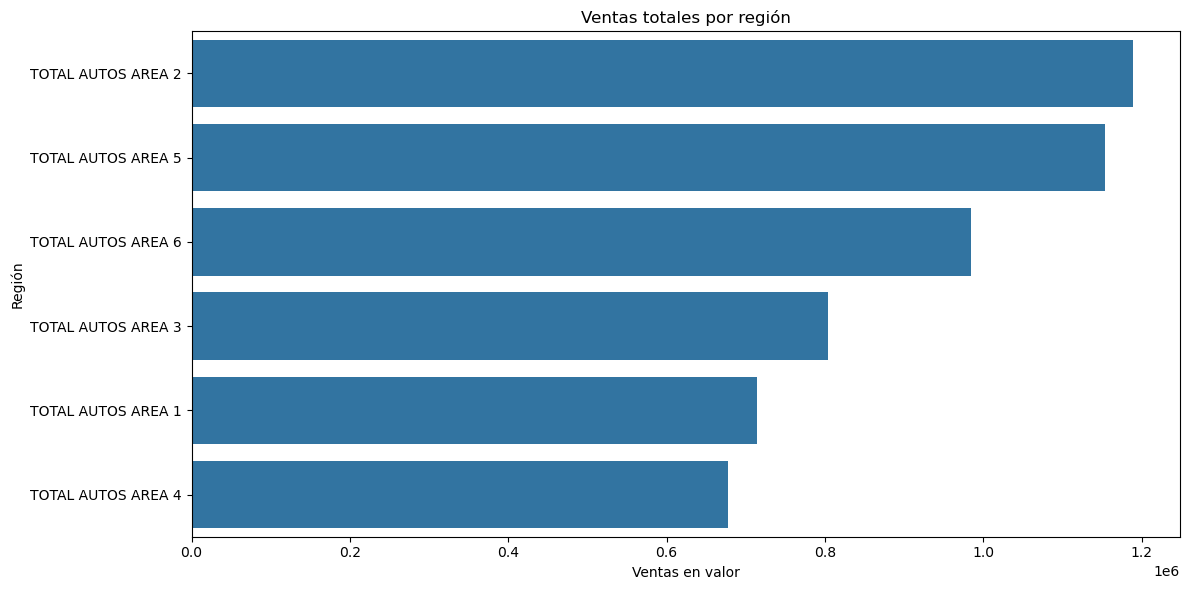

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=ventas_region,x="total_value_sales",y="REGION")
plt.title("Ventas totales por región")
plt.xlabel("Ventas en valor")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

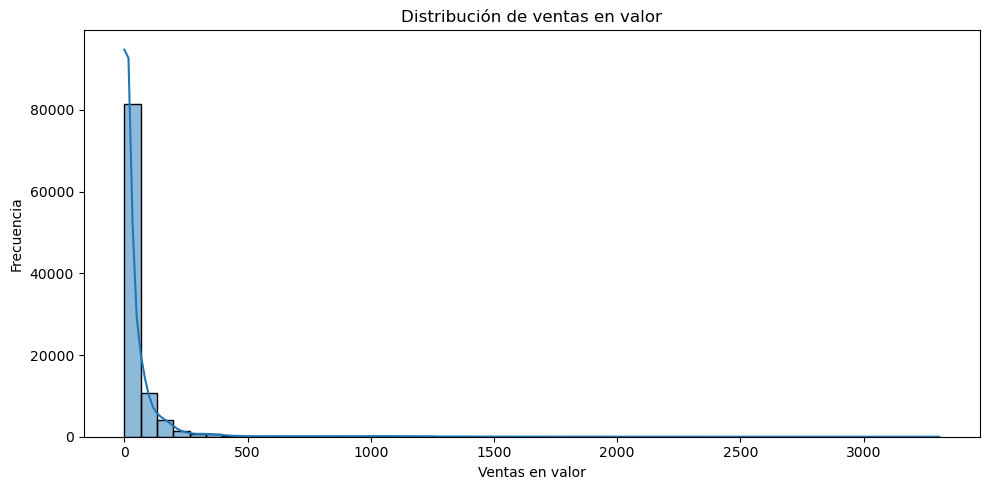

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(consolidated_df_areas["TOTAL_VALUE_SALES"],bins=50,kde=True)
plt.title("Distribución de ventas en valor")
plt.xlabel("Ventas en valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

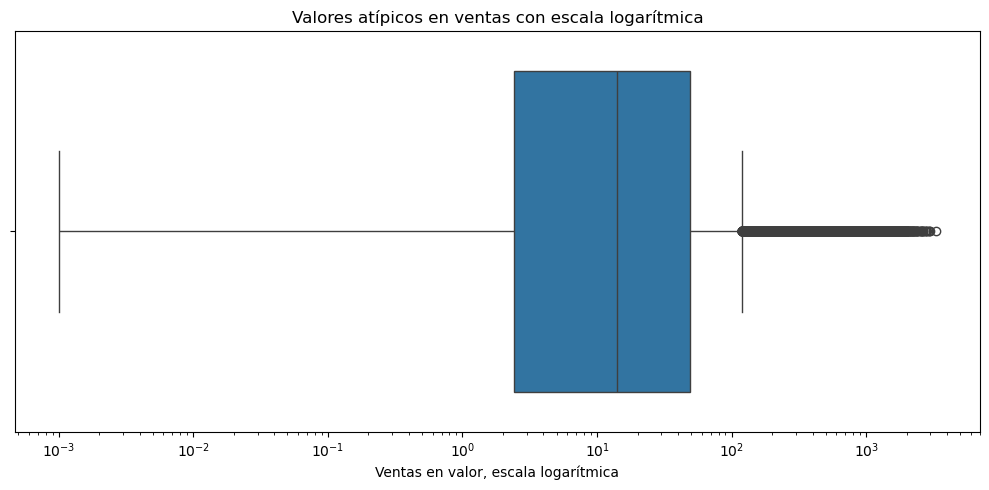

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=consolidated_df_areas,x="TOTAL_VALUE_SALES")
plt.xscale("log")
plt.title("Valores atípicos en ventas con escala logarítmica")
plt.xlabel("Ventas en valor, escala logarítmica")
plt.tight_layout()
plt.show()

In [28]:
ventas_tiempo = (consolidated_df_areas.groupby("DATE", as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("DATE"))
ventas_tiempo

,DATE,total_value_sales,total_unit_sales
0,2022-01-09,"75,769.46","2,830.92"
1,2022-01-16,"73,498.51","2,843.07"
2,2022-01-23,"62,675.67","2,422.44"
3,2022-01-30,"61,972.82","2,396.79"
4,2022-02-06,"64,920.90","2,510.64"
...,...,...,...
75,2023-06-19,"74,571.57","2,512.31"
76,2023-06-26,"71,546.08","2,425.51"
77,2023-07-03,"84,002.68","2,938.85"
78,2023-07-10,"79,175.66","2,657.56"


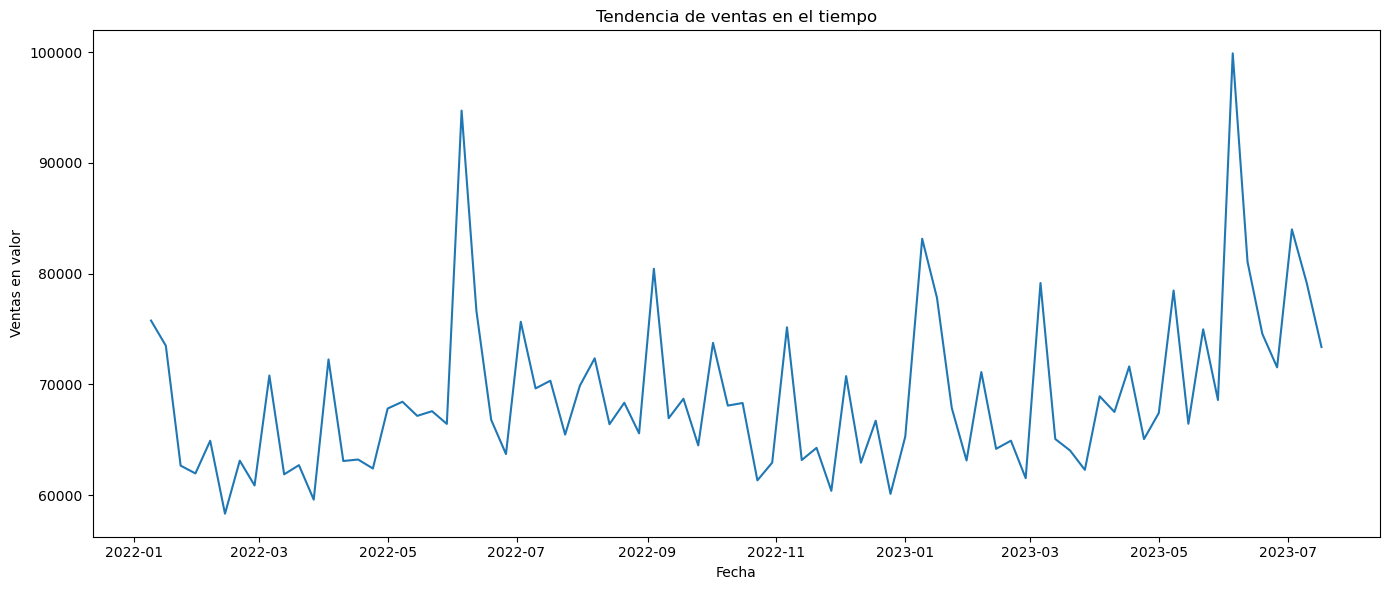

In [29]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=ventas_tiempo,x="DATE",y="total_value_sales")
plt.title("Tendencia de ventas en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas en valor")
plt.tight_layout()
plt.show()

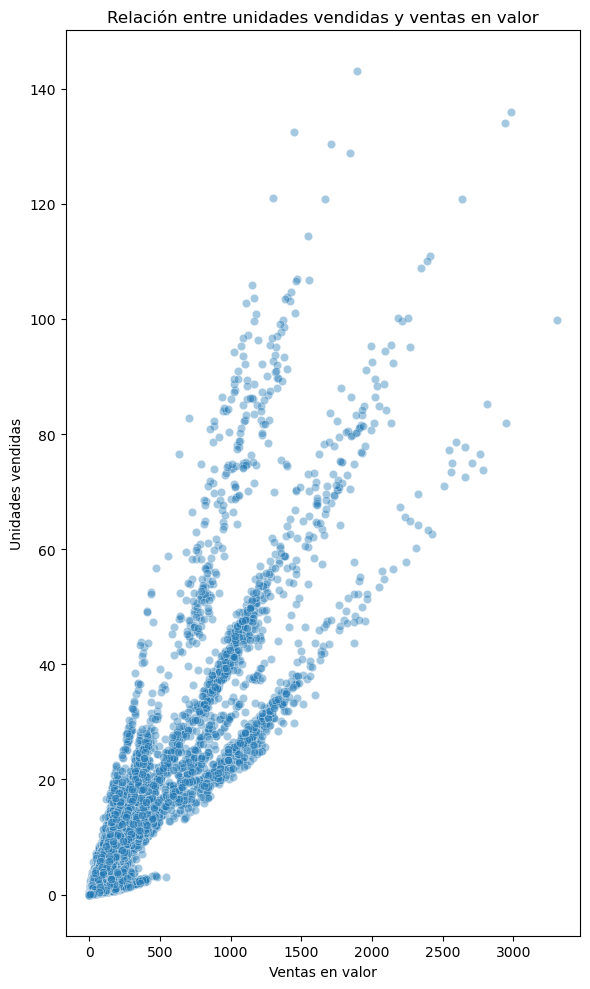

In [30]:
plt.figure(figsize=(6, 10))
sns.scatterplot(data=consolidated_df_areas,y="TOTAL_UNIT_SALES",x="TOTAL_VALUE_SALES",alpha=0.4)
plt.title("Relación entre unidades vendidas y ventas en valor")
plt.ylabel("Unidades vendidas")
plt.xlabel("Ventas en valor")
plt.tight_layout()
plt.show()

In [31]:
top_productos = (consolidated_df_areas.groupby(["ITEM_KEY", "ITEM_DESCRIPTION"], as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("total_value_sales", ascending=False).head(10))
top_productos

,ITEM_KEY,ITEM_DESCRIPTION,total_value_sales,total_unit_sales
51,75000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,"573,424.82","14,167.21"
50,75000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,"569,616.89","24,222.58"
49,75000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,"329,292.28","23,230.92"
87,7501025402051,BLANCATEL CONCENTRADO BOT PLAST 3750ML NAL 750...,"245,537.61","7,806.60"
227,7501071900143,CLOROX REGULAR CONCENTRADO BOTPLAST.3800ML 750...,"199,997.39","5,564.61"
99,7501025405212,CLORALEX ULTRAGEL CLORO EN GEL CONCENTRADO 950...,"121,090.57","4,833.54"
129,7501025450212,CLORALEX EL RENDIDOR BOT 1900+100ML= 2LT 75010...,"120,749.44","5,039.85"
95,7501025405090,CLORALEX ULTRAGEL CLORO GEL CONCENTRADO BOT 60...,"117,892.20","7,015.70"
97,7501025405151,CLORALEX CLORO EN GEL BOT 950ML 7501025405151,"99,905.73","5,484.35"
96,7501025405106,CLORALEX CLORO EN GEL BP 2000ML 7501025405106,"87,555.50","2,812.23"


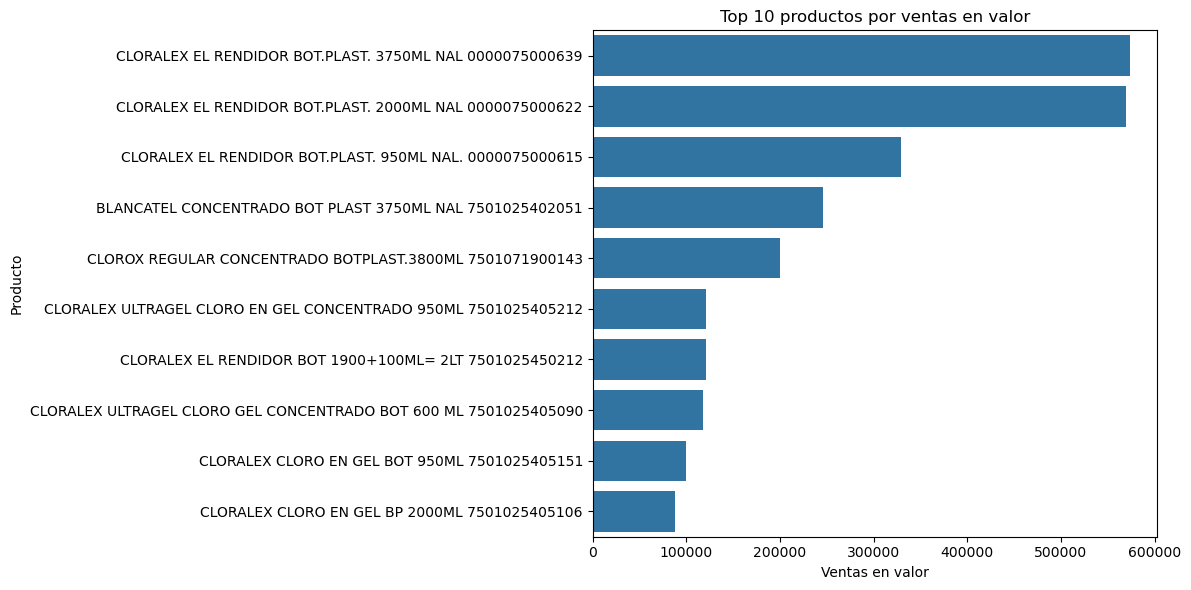

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_productos,x="total_value_sales",y="ITEM_DESCRIPTION")
plt.title("Top 10 productos por ventas en valor")
plt.xlabel("Ventas en valor")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

In [33]:
top_marcas = (consolidated_df_areas.groupby("BRAND", as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("total_value_sales", ascending=False).head(10))

top_marcas

,BRAND,total_value_sales,total_unit_sales
4,CLORALEX,"2,696,809.34","111,650.34"
23,VANISH,"1,084,144.86","27,666.49"
6,CLOROX,"685,875.94","23,940.61"
2,BLANCATEL,"326,242.02","10,305.65"
17,OXI CLEAN,"218,485.40","3,039.69"
9,DR.BECKMANN,"139,859.65","2,614.67"
0,BANDERA,"134,968.52","6,061.55"
14,LOS PATITOS,"71,372.85","3,390.85"
3,CLARASOL,"70,506.10","4,910.57"
15,LYSOL,"35,278.68",264.75


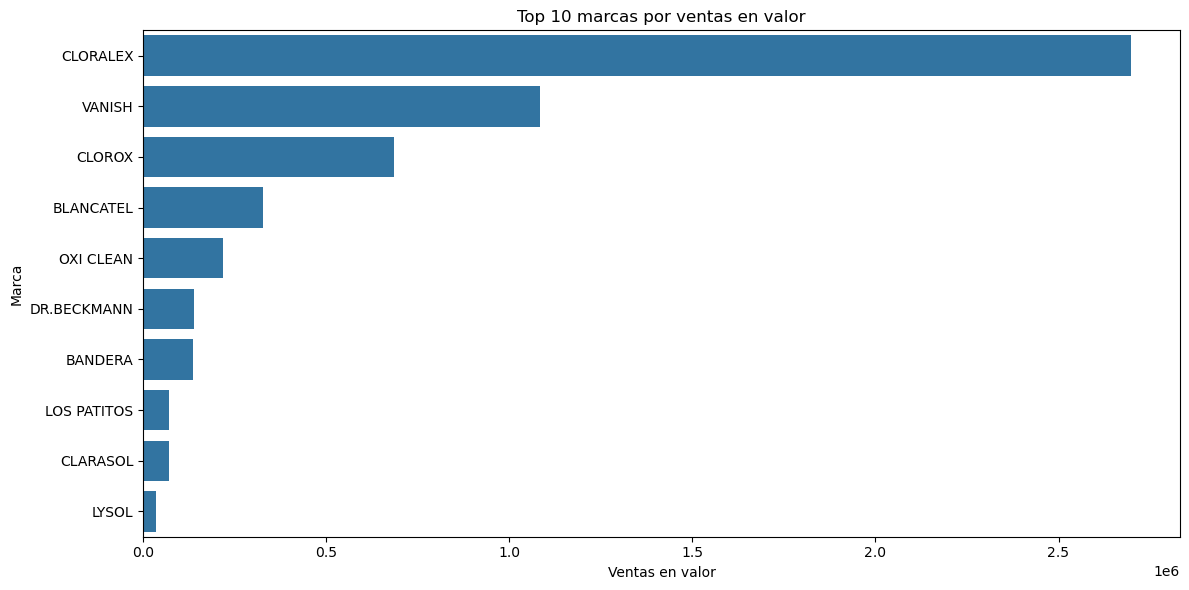

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_marcas,x="total_value_sales",y="BRAND")
plt.title("Top 10 marcas por ventas en valor")
plt.xlabel("Ventas en valor")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

In [35]:
ventas_region_segmento = (consolidated_df_areas
    .groupby(["REGION", "SEGMENT"], as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("total_value_sales", ascending=False))
ventas_region_segmento.head(20)

,REGION,SEGMENT,total_value_sales,total_unit_sales
8,TOTAL AUTOS AREA 2,BLEACH,"862,603.78","36,967.56"
36,TOTAL AUTOS AREA 6,BLEACH,"758,386.09","32,530.56"
29,TOTAL AUTOS AREA 5,BLEACH,"673,066.30","26,504.82"
1,TOTAL AUTOS AREA 1,BLEACH,"519,129.93","21,174.40"
15,TOTAL AUTOS AREA 3,BLEACH,"515,587.42","19,420.95"
22,TOTAL AUTOS AREA 4,BLEACH,"461,868.67","18,745.42"
30,TOTAL AUTOS AREA 5,LIQUID & GEL,"201,428.36","3,998.81"
32,TOTAL AUTOS AREA 5,POWDER,"155,412.38","2,202.70"
9,TOTAL AUTOS AREA 2,LIQUID & GEL,"135,683.55","2,880.36"
16,TOTAL AUTOS AREA 3,LIQUID & GEL,"123,604.98","2,544.86"


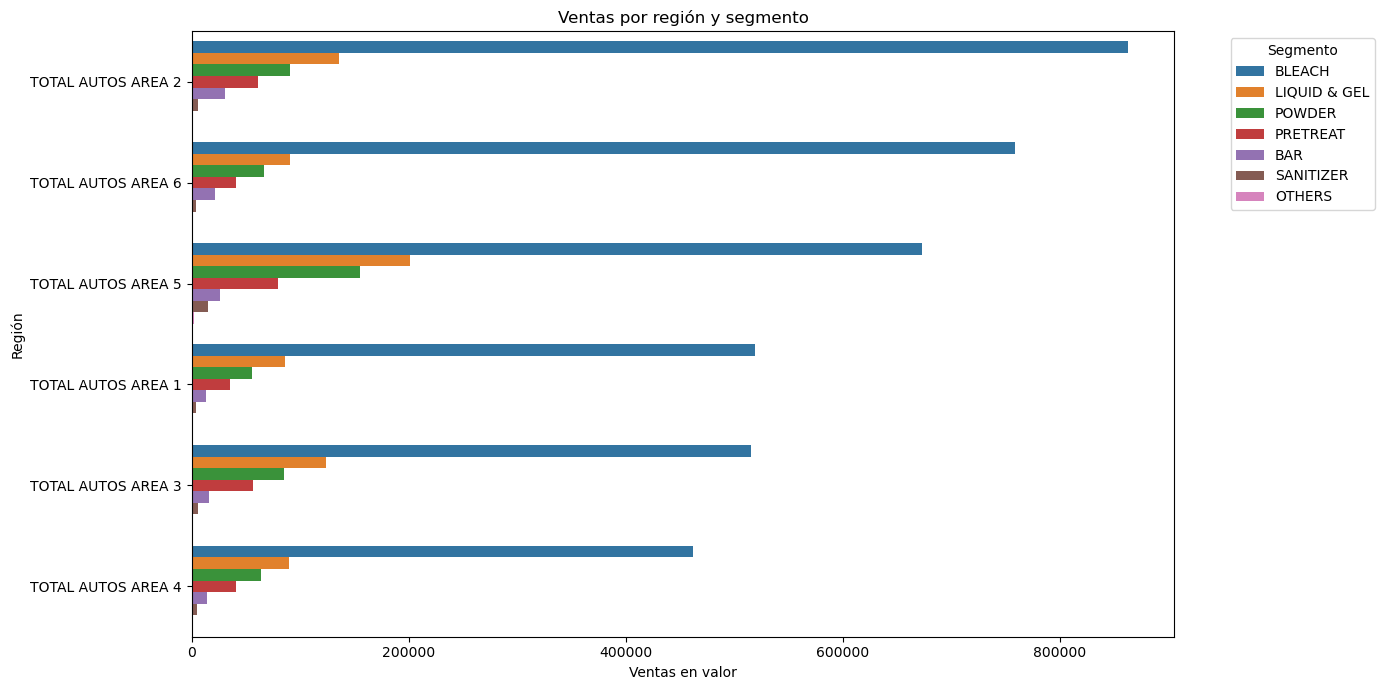

In [36]:
plt.figure(figsize=(14, 7))
sns.barplot(data=ventas_region_segmento,x="total_value_sales",y="REGION",hue="SEGMENT")
plt.title("Ventas por región y segmento")
plt.xlabel("Ventas en valor")
plt.ylabel("Región")
plt.legend(title="Segmento", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [37]:
heatmap_region_segmento = ventas_region_segmento.pivot_table(index="REGION",columns="SEGMENT",values="total_value_sales",aggfunc="sum",fill_value=0)
heatmap_region_segmento

SEGMENT,BAR,BLEACH,LIQUID & GEL,OTHERS,POWDER,PRETREAT,SANITIZER
REGION,,,,,,,
TOTAL AUTOS AREA 1,"13,280.38","519,129.93","86,200.06",717.27,"55,615.15","35,083.69","4,223.50"
TOTAL AUTOS AREA 2,"30,734.95","862,603.78","135,683.55","1,583.90","90,588.85","61,344.01","6,257.12"
TOTAL AUTOS AREA 3,"15,809.77","515,587.42","123,604.98","1,386.91","85,036.87","56,714.33","5,515.06"
TOTAL AUTOS AREA 4,"14,424.57","461,868.67","89,566.97",867.35,"63,923.66","41,435.39","5,349.37"
TOTAL AUTOS AREA 5,"25,858.19","673,066.30","201,428.36","2,462.47","155,412.38","80,053.45","15,054.39"
TOTAL AUTOS AREA 6,"21,661.81","758,386.09","90,544.22",502.80,"66,933.97","41,370.25","4,558.43"


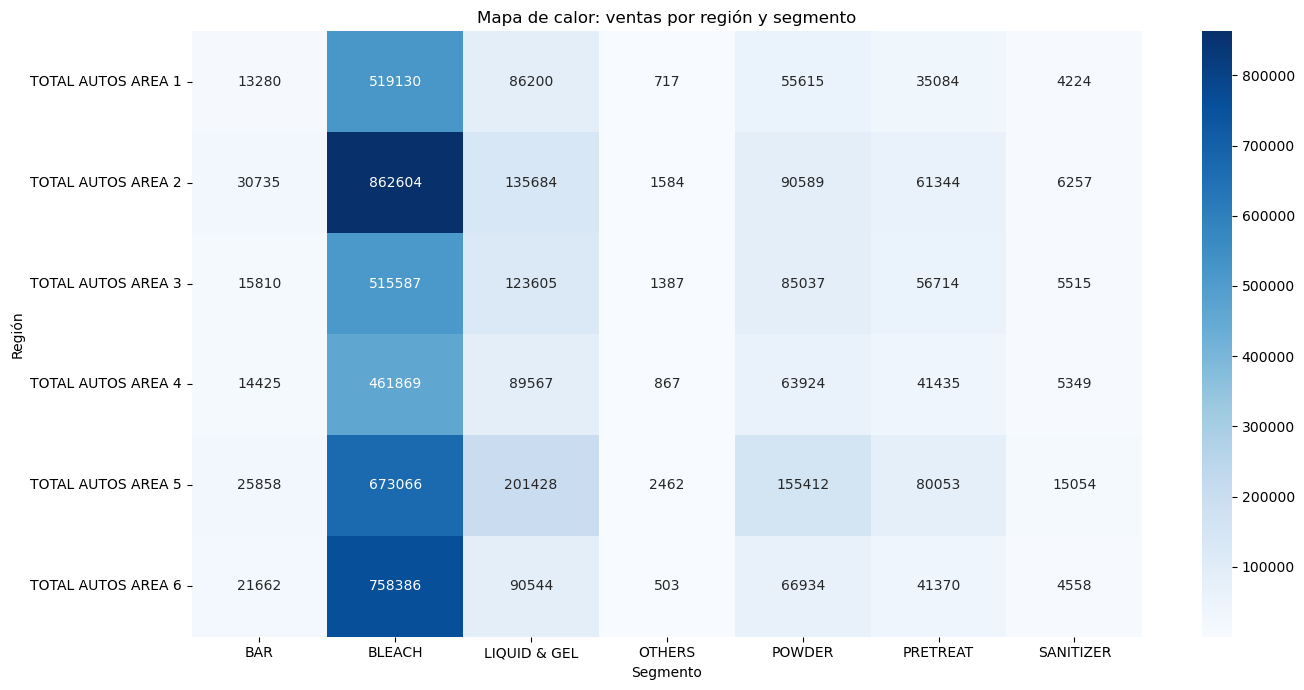

In [38]:
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_region_segmento,annot=True,fmt=".0f",cmap="Blues")
plt.title("Mapa de calor: ventas por región y segmento")
plt.xlabel("Segmento")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

In [39]:
resumen_region = (consolidated_df_areas.groupby("REGION", as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum"),avg_weekly_sales=("TOTAL_UNIT_AVG_WEEKLY_SALES", "mean"),
        productos_unicos=("ITEM_KEY", "nunique"),marcas_unicas=("BRAND", "nunique")).sort_values("total_value_sales", ascending=False))
resumen_region

,REGION,total_value_sales,total_unit_sales,avg_weekly_sales,productos_unicos,marcas_unicas
1,TOTAL AUTOS AREA 2,"1,188,796.15","45,319.92",9.76,291,21
4,TOTAL AUTOS AREA 5,"1,153,335.54","36,266.90",10.85,255,18
5,TOTAL AUTOS AREA 6,"983,957.57","38,585.22",10.85,268,19
2,TOTAL AUTOS AREA 3,"803,655.34","25,896.05",10.99,260,19
0,TOTAL AUTOS AREA 1,"714,249.98","25,791.93",8.16,279,20
3,TOTAL AUTOS AREA 4,"677,436.00","24,020.15",9.00,271,19


In [40]:
resumen_segmento = (consolidated_df_areas.groupby("SEGMENT", as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum"),avg_weekly_sales=("TOTAL_UNIT_AVG_WEEKLY_SALES", "mean"),productos_unicos=("ITEM_KEY", "nunique"),
        marcas_unicas=("BRAND", "nunique")).sort_values("total_value_sales", ascending=False))
resumen_segmento

,SEGMENT,total_value_sales,total_unit_sales,avg_weekly_sales,productos_unicos,marcas_unicas
1,BLEACH,"3,790,642.19","155,343.72",17.01,176,17
2,LIQUID & GEL,"727,028.13","15,157.15",4.96,57,5
4,POWDER,"517,510.89","8,875.98",3.69,49,5
5,PRETREAT,"316,001.11","6,959.88",3.83,48,9
0,BAR,"121,769.67","9,084.31",14.71,8,2
6,SANITIZER,"40,957.87",357.09,1.95,11,3
3,OTHERS,"7,520.71",102.04,2.77,1,1


In [41]:
resumen_marca = (consolidated_df_areas.groupby("BRAND", as_index=False).agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),
        total_unit_sales=("TOTAL_UNIT_SALES", "sum"),productos_unicos=("ITEM_KEY", "nunique")).sort_values("total_value_sales", ascending=False))
resumen_marca.head(20)

,BRAND,total_value_sales,total_unit_sales,productos_unicos
4,CLORALEX,"2,696,809.34","111,650.34",77
23,VANISH,"1,084,144.86","27,666.49",77
6,CLOROX,"685,875.94","23,940.61",61
2,BLANCATEL,"326,242.02","10,305.65",8
17,OXI CLEAN,"218,485.40","3,039.69",19
9,DR.BECKMANN,"139,859.65","2,614.67",22
0,BANDERA,"134,968.52","6,061.55",21
14,LOS PATITOS,"71,372.85","3,390.85",5
3,CLARASOL,"70,506.10","4,910.57",5
15,LYSOL,"35,278.68",264.75,8


# Segmentación K-Means

In [42]:
productos_cluster = (consolidated_df_areas.groupby(["ITEM_KEY", "ITEM_DESCRIPTION", "BRAND", "SEGMENT", "FORMAT"], as_index=False)
    .agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),total_unit_sales=("TOTAL_UNIT_SALES", "sum"),
        avg_weekly_sales=("TOTAL_UNIT_AVG_WEEKLY_SALES", "mean"),regiones_activas=("REGION", "nunique"),semanas_activas=("WEEK", "nunique")))
productos_cluster.head()

,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas
0,123456808218,CLORALEX REGULAR BOT 950 ML NAL 0123456808218,CLORALEX,BLEACH,LIQUIDO,0.02,0.00,1.00,1,1
1,19200958714,LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 1.2 ...,LYSOL,SANITIZER,LIQUIDO,0.24,0.00,1.00,1,2
2,3045200760009,SANYTOL DESINFECTANTE DE ROPA BOT 500 ML 30452...,SANYTOL,SANITIZER,LIQUIDO,"4,281.18",77.76,2.56,6,80
3,3045206360609,SANYTOL DESINFECTANTE DE ROPA BOT 1 LT 3045206...,SANYTOL,SANITIZER,LIQUIDO,"1,268.93",12.00,1.71,6,80
4,3045206382007,SANYTOL QUITAMANCHAS DESINFECTANTE POLVO BOT 4...,SANYTOL,POWDER,POLVO,"1,453.70",17.56,1.69,6,80


In [43]:
variables_cluster = ["total_value_sales","total_unit_sales","avg_weekly_sales","regiones_activas","semanas_activas"]
X_cluster = productos_cluster[variables_cluster].copy()
X_cluster.head()

,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas
0,0.02,0.00,1.00,1,1
1,0.24,0.00,1.00,1,2
2,"4,281.18",77.76,2.56,6,80
3,"1,268.93",12.00,1.71,6,80
4,"1,453.70",17.56,1.69,6,80


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]

array([[-0.3038936 , -0.26155367, -0.38505592, -1.80040506, -1.95010255],
       [-0.30388934, -0.26155321, -0.38505592, -1.80040506, -1.91703395],
       [-0.22142271, -0.2252142 , -0.30291757,  0.67267881,  0.66231681],
       [-0.27944961, -0.25594411, -0.34779481,  0.67267881,  0.66231681],
       [-0.27589035, -0.25334566, -0.34862163,  0.67267881,  0.66231681]])

In [45]:
from sklearn.cluster import KMeans
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

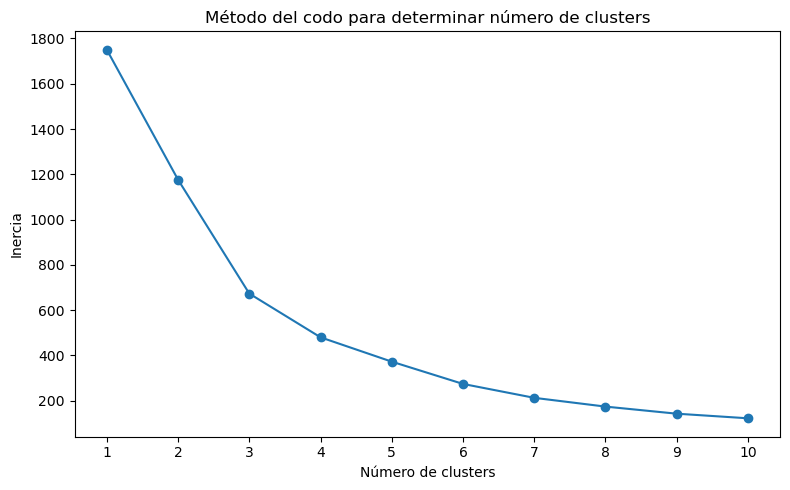

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.title("Método del codo para determinar número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range_silhouette = range(2, 11)
for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k,n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
silhouette_resultados = pd.DataFrame({"k": list(k_range_silhouette),"silhouette_score": silhouette_scores})
silhouette_resultados

,k,silhouette_score
0,2,0.85
1,3,0.57
2,4,0.59
3,5,0.57
4,6,0.61
5,7,0.61
6,8,0.62
7,9,0.61
8,10,0.60


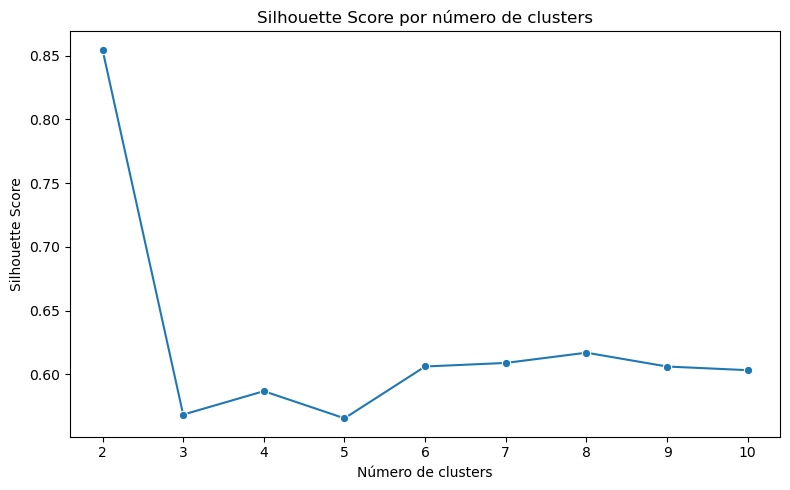

In [48]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=silhouette_resultados,x="k",y="silhouette_score",marker="o")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range_silhouette))
plt.tight_layout()
plt.show()

In [49]:
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo,n_init=10)
productos_cluster["CLUSTER"] = kmeans_final.fit_predict(X_scaled)
productos_cluster.head()

,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas,CLUSTER
0,123456808218,CLORALEX REGULAR BOT 950 ML NAL 0123456808218,CLORALEX,BLEACH,LIQUIDO,0.02,0.00,1.00,1,1,1
1,19200958714,LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 1.2 ...,LYSOL,SANITIZER,LIQUIDO,0.24,0.00,1.00,1,2,1
2,3045200760009,SANYTOL DESINFECTANTE DE ROPA BOT 500 ML 30452...,SANYTOL,SANITIZER,LIQUIDO,"4,281.18",77.76,2.56,6,80,0
3,3045206360609,SANYTOL DESINFECTANTE DE ROPA BOT 1 LT 3045206...,SANYTOL,SANITIZER,LIQUIDO,"1,268.93",12.00,1.71,6,80,0
4,3045206382007,SANYTOL QUITAMANCHAS DESINFECTANTE POLVO BOT 4...,SANYTOL,POWDER,POLVO,"1,453.70",17.56,1.69,6,80,0


In [50]:
resumen_clusters = (productos_cluster.groupby("CLUSTER", as_index=False).agg(productos=("ITEM_KEY", "nunique"),
        total_value_sales=("total_value_sales", "sum"),total_unit_sales=("total_unit_sales", "sum"),avg_value_sales=("total_value_sales", "mean"),
        avg_unit_sales=("total_unit_sales", "mean"),avg_weekly_sales=("avg_weekly_sales", "mean"),avg_regiones_activas=("regiones_activas", "mean"),
        avg_semanas_activas=("semanas_activas", "mean")))
resumen_clusters

,CLUSTER,productos,total_value_sales,total_unit_sales,avg_value_sales,avg_unit_sales,avg_weekly_sales,avg_regiones_activas,avg_semanas_activas
0,0,249,"3,664,376.83","120,579.60","14,716.37",484.26,7.46,5.71,74.66
1,1,94,"14,282.13",377.19,151.94,4.01,2.84,1.78,19.57
2,2,3,"1,472,334.00","61,620.71","490,778.00","20,540.24",88.22,6.00,80.00
3,3,4,"370,437.62","13,302.67","92,609.40","3,325.67",129.80,4.00,80.00


In [51]:
perfil_clusters = (productos_cluster.groupby("CLUSTER")[variables_cluster].mean().round(2))
perfil_clusters

,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas
CLUSTER,,,,,
0,"14,716.37",484.26,7.46,5.71,74.66
1,151.94,4.01,2.84,1.78,19.57
2,"490,778.00","20,540.24",88.22,6.00,80.00
3,"92,609.40","3,325.67",129.80,4.00,80.00


In [52]:
for cluster in sorted(productos_cluster["CLUSTER"].unique()):
    print(f"\nCLUSTER {cluster}") 
    display(productos_cluster[productos_cluster["CLUSTER"] == cluster].sort_values("total_value_sales", ascending=False).head(5))


CLUSTER 0


,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas,CLUSTER
227,7501071900143,CLOROX REGULAR CONCENTRADO BOTPLAST.3800ML 750...,CLOROX,BLEACH,LIQUIDO,"199,997.39","5,564.61",26.44,6,80,0
99,7501025405212,CLORALEX ULTRAGEL CLORO EN GEL CONCENTRADO 950...,CLORALEX,BLEACH,GEL,"121,090.57","4,833.54",26.88,6,80,0
95,7501025405090,CLORALEX ULTRAGEL CLORO GEL CONCENTRADO BOT 60...,CLORALEX,BLEACH,GEL,"117,892.20","7,015.70",32.38,6,80,0
97,7501025405151,CLORALEX CLORO EN GEL BOT 950ML 7501025405151,CLORALEX,BLEACH,GEL,"99,905.73","5,484.35",24.37,6,80,0
96,7501025405106,CLORALEX CLORO EN GEL BP 2000ML 7501025405106,CLORALEX,BLEACH,GEL,"87,555.50","2,812.23",18.58,6,80,0



CLUSTER 1


,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas,CLUSTER
109,7501025408404,CLORALEX AROMAS BLAQUEADOR LIQUIDO FLORAL GAR ...,CLORALEX,BLEACH,LIQUIDO,"4,072.10",38.55,8.01,1,55,1
303,7501681100209,BANDERA BOT PLAST LAVANDA 3.8LT NAL 7501681100209,BANDERA,BLEACH,LIQUIDO,"2,629.90",79.70,13.63,1,80,1
304,7501681100216,BANDERA BOT PLAST LIMON 3.8LT NAL 7501681100216,BANDERA,BLEACH,LIQUIDO,"2,389.65",72.36,12.49,1,80,1
324,7502267450312,STORM DESINFECTANTE Y BLANCURA BOTE DE 3.785 7...,OTHERS MARCA UNIF.,BLEACH,LIQUIDO,"1,662.56",61.52,37.77,1,56,1
136,7501042300033,PATITO CLORO PATITO BOT.PLAST.960 ML NAL. 7501...,PATITO,BLEACH,LIQUIDO,801.34,65.32,16.71,1,80,1



CLUSTER 2


,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas,CLUSTER
51,75000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,CLORALEX,BLEACH,LIQUIDO,"573,424.82","14,167.21",60.57,6,80,2
50,75000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,CLORALEX,BLEACH,LIQUIDO,"569,616.89","24,222.58",112.22,6,80,2
49,75000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,CLORALEX,BLEACH,LIQUIDO,"329,292.28","23,230.92",91.88,6,80,2



CLUSTER 3


,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,total_value_sales,total_unit_sales,avg_weekly_sales,regiones_activas,semanas_activas,CLUSTER
87,7501025402051,BLANCATEL CONCENTRADO BOT PLAST 3750ML NAL 750...,BLANCATEL,BLEACH,LIQUIDO,"245,537.61","7,806.60",43.23,6,80,3
129,7501025450212,CLORALEX EL RENDIDOR BOT 1900+100ML= 2LT 75010...,CLORALEX,BLEACH,LIQUIDO,"120,749.44","5,039.85",125.04,6,80,3
68,7501025401252,CLORALUZ BOT.PLAST. 900ML NAL. 7501025401252,CLORALUZ,BLEACH,LIQUIDO,"3,687.39",399.01,96.69,1,80,3
300,7501681100018,BANDERA BLANQUEADOR LIMPIA DESEINFECTA BOT PLA...,BANDERA,BLEACH,LIQUIDO,463.17,57.21,254.25,3,80,3


In [53]:
cluster_names = {0: "Productos de volumen acumulado",1: "Productos de baja contribución",2: "Productos Líder",3: "Productos de presencia específica"}
productos_cluster["CLUSTER_NAME"] = productos_cluster["CLUSTER"].map(cluster_names)
productos_cluster[["ITEM_KEY","ITEM_DESCRIPTION","BRAND","SEGMENT","FORMAT","CLUSTER","CLUSTER_NAME"]]

,ITEM_KEY,ITEM_DESCRIPTION,BRAND,SEGMENT,FORMAT,CLUSTER,CLUSTER_NAME
0,123456808218,CLORALEX REGULAR BOT 950 ML NAL 0123456808218,CLORALEX,BLEACH,LIQUIDO,1,Productos de baja contribución
1,19200958714,LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 1.2 ...,LYSOL,SANITIZER,LIQUIDO,1,Productos de baja contribución
2,3045200760009,SANYTOL DESINFECTANTE DE ROPA BOT 500 ML 30452...,SANYTOL,SANITIZER,LIQUIDO,0,Productos de volumen acumulado
3,3045206360609,SANYTOL DESINFECTANTE DE ROPA BOT 1 LT 3045206...,SANYTOL,SANITIZER,LIQUIDO,0,Productos de volumen acumulado
4,3045206382007,SANYTOL QUITAMANCHAS DESINFECTANTE POLVO BOT 4...,SANYTOL,POWDER,POLVO,0,Productos de volumen acumulado
...,...,...,...,...,...,...,...
345,7891035040276,VANISH SUPER BARRA WHITE QUITA MANCHAS 68GR 78...,VANISH,BAR,BARRA,0,Productos de volumen acumulado
346,8410907050053,IBERIA BLANCO NUCLEAR BLANQUEADOR REG CAJA 6SO...,IBERIA,BLEACH,POLVO,0,Productos de volumen acumulado
347,8411660210012,IBERIA REVOLUTION QUITA MANCHAS DIARIAS ROLL O...,IBERIA,PRETREAT,LIQUIDO,0,Productos de volumen acumulado
348,8411660210029,IBERIA REVOLUTION QUITA MANCHAS RESISTENTES BO...,IBERIA,PRETREAT,LIQUIDO,0,Productos de volumen acumulado


In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
productos_cluster["PCA_1"] = pca_result[:, 0]
productos_cluster["PCA_2"] = pca_result[:, 1]
print("Varianza explicada por PCA:")
print(pca.explained_variance_ratio_)

Varianza explicada por PCA:
[0.49945011 0.29461949]


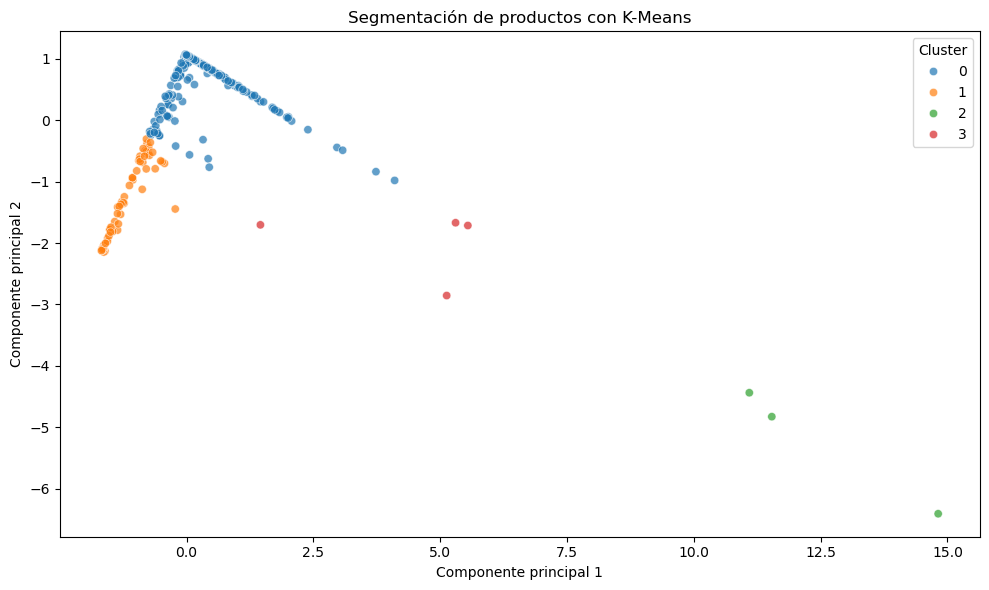

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=productos_cluster,x="PCA_1",y="PCA_2",hue="CLUSTER",alpha=0.7,palette="tab10")
plt.title("Segmentación de productos con K-Means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

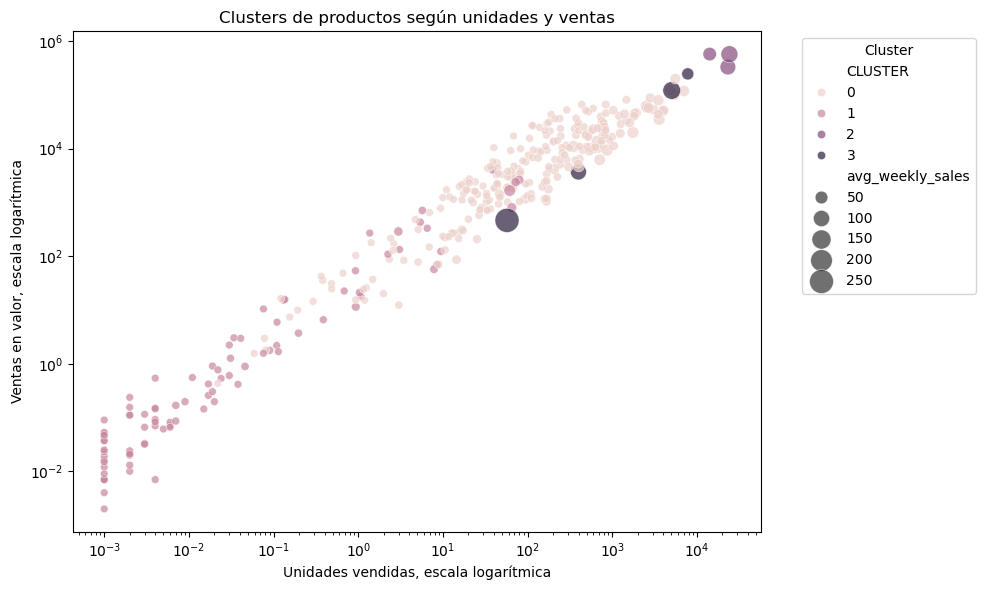

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=productos_cluster,x="total_unit_sales",y="total_value_sales",hue="CLUSTER",size="avg_weekly_sales",sizes=(30, 300),alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.title("Clusters de productos según unidades y ventas")
plt.xlabel("Unidades vendidas, escala logarítmica")
plt.ylabel("Ventas en valor, escala logarítmica")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [57]:
fact_sales_sql = consolidated_df_areas.copy()
fact_sales_mexico_sql = consolidated_df_mexico.copy()
product_cluster_sql = productos_cluster.copy()
resumen_clusters_sql = resumen_clusters.copy()
resumen_region_sql = resumen_region.copy()
resumen_segmento_sql = resumen_segmento.copy()
resumen_marca_sql = resumen_marca.copy()
columnas_redundantes = ["ITEM", "ITEM_CODE"]
tablas_exportacion = {"FACT_SALES_CLEAN_AREAS": fact_sales_sql,"FACT_SALES_CLEAN_MEXICO": fact_sales_mexico_sql,"PRODUCT_CLUSTER": product_cluster_sql,
    "RESUMEN_CLUSTERS": resumen_clusters_sql,"RESUMEN_REGION": resumen_region_sql,"RESUMEN_SEGMENTO": resumen_segmento_sql,
    "RESUMEN_MARCA": resumen_marca_sql}
for nombre, df in tablas_exportacion.items():
    df.drop(columns=columnas_redundantes, errors="ignore", inplace=True)
print("Tablas preparadas para exportación.")

Tablas preparadas para exportación.


In [58]:
import os
print("Carpeta actual del notebook:")
print(os.getcwd())

Carpeta actual del notebook:
C:\Users\Alexis Takahashi


In [59]:
for nombre, df in tablas_exportacion.items():
    columnas_encontradas = [col for col in ["ITEM", "ITEM_CODE"] if col in df.columns]
    
    if columnas_encontradas:
        print(f"{nombre}: contiene {columnas_encontradas}")
    else:
        print(f"{nombre}: OK")

FACT_SALES_CLEAN_AREAS: OK
FACT_SALES_CLEAN_MEXICO: OK
PRODUCT_CLUSTER: OK
RESUMEN_CLUSTERS: OK
RESUMEN_REGION: OK
RESUMEN_SEGMENTO: OK
RESUMEN_MARCA: OK


In [60]:
fact_sales_sql.to_csv("FACT_SALES_CLEAN_AREAS.csv", index=False)
fact_sales_mexico_sql.to_csv("FACT_SALES_CLEAN_MEXICO.csv", index=False)
product_cluster_sql.to_csv("PRODUCT_CLUSTER.csv", index=False)
resumen_clusters_sql.to_csv("RESUMEN_CLUSTERS.csv", index=False)
resumen_region_sql.to_csv("RESUMEN_REGION.csv", index=False)
resumen_segmento_sql.to_csv("RESUMEN_SEGMENTO.csv", index=False)
resumen_marca_sql.to_csv("RESUMEN_MARCA.csv", index=False)
print("Archivos SQL exportados")

Archivos SQL exportados


# Predicción de Ventas con modelo ARIMA

In [61]:
ventas_semanales_modelo = (consolidated_df_areas.groupby(["YEAR", "WEEK_NUMBER", "DATE"], as_index=False)
    .agg(total_value_sales=("TOTAL_VALUE_SALES", "sum"),total_unit_sales=("TOTAL_UNIT_SALES", "sum")).sort_values("DATE"))
ventas_semanales_modelo = ventas_semanales_modelo.reset_index(drop=True)
ventas_semanales_modelo.head()

,YEAR,WEEK_NUMBER,DATE,total_value_sales,total_unit_sales
0,2022,1,2022-01-09,"75,769.46","2,830.92"
1,2022,2,2022-01-16,"73,498.51","2,843.07"
2,2022,3,2022-01-23,"62,675.67","2,422.44"
3,2022,4,2022-01-30,"61,972.82","2,396.79"
4,2022,5,2022-02-06,"64,920.90","2,510.64"


In [62]:
serie_arima = ventas_semanales_modelo.set_index("DATE")["total_value_sales"]
serie_arima = serie_arima.sort_index()
serie_arima

DATE
2022-01-09   75,769.46
2022-01-16   73,498.51
2022-01-23   62,675.67
2022-01-30   61,972.82
2022-02-06   64,920.90
                ...   
2023-06-19   74,571.57
2023-06-26   71,546.08
2023-07-03   84,002.68
2023-07-10   79,175.66
2023-07-17   73,384.99
Name: total_value_sales, Length: 80, dtype: float64

In [63]:
from statsmodels.tsa.stattools import adfuller
resultado_adf = adfuller(serie_arima.dropna())
print("Dickey-Fuller - Serie original")
print("ADF Statistic:", resultado_adf[0])
print("p-value:", resultado_adf[1])
if resultado_adf[1] <= 0.05:
    print("La serie original es estacionaria.")
else:
    print("La serie original no es estacionaria.")

Dickey-Fuller - Serie original
ADF Statistic: -0.9743203156675495
p-value: 0.7625147867082116
La serie original no es estacionaria.


In [64]:
serie_arima_diff1 = serie_arima.diff().dropna()
resultado_adf_diff1 = adfuller(serie_arima_diff1)
print("Dickey-Fuller - Primera diferenciación")
print("ADF Statistic:", resultado_adf_diff1[0])
print("p-value:", resultado_adf_diff1[1])
if resultado_adf_diff1[1] <= 0.05:
    print("La serie con primera diferenciación es estacionaria.")
else:
    print("La serie con primera diferenciación aún no es estacionaria.")

Dickey-Fuller - Primera diferenciación
ADF Statistic: -2.8166230272387405
p-value: 0.055938238835548756
La serie con primera diferenciación aún no es estacionaria.


In [65]:
serie_arima_diff2 = serie_arima.diff().diff().dropna()
resultado_adf_diff2 = adfuller(serie_arima_diff2)
print("Dickey-Fuller - Segunda diferenciación")
print("ADF Statistic:", resultado_adf_diff2[0])
print("p-value:", resultado_adf_diff2[1])
if resultado_adf_diff2[1] <= 0.05:
    print("La serie con segunda diferenciación es estacionaria.")
else:
    print("La serie con segunda diferenciación aún no es estacionaria.")

Dickey-Fuller - Segunda diferenciación
ADF Statistic: -4.261590239447269
p-value: 0.0005173917490461571
La serie con segunda diferenciación es estacionaria.


In [66]:
if resultado_adf[1] <= 0.05:
    d_optimo = 0
elif resultado_adf_diff1[1] <= 0.05:
    d_optimo = 1
elif resultado_adf_diff2[1] <= 0.05:
    d_optimo = 2
else:
    d_optimo = 1
print("Valor de d seleccionado:", d_optimo)

Valor de d seleccionado: 2


In [67]:
serie_arima = ventas_semanales_modelo.set_index("DATE")["total_value_sales"]
serie_arima = serie_arima.sort_index()
print("Valores faltantes:", serie_arima.isna().sum())
serie_arima.head()

Valores faltantes: 0


DATE
2022-01-09   75,769.46
2022-01-16   73,498.51
2022-01-23   62,675.67
2022-01-30   61,972.82
2022-02-06   64,920.90
Name: total_value_sales, dtype: float64

In [68]:
split_arima = int(len(serie_arima) * 0.8)
train_arima = serie_arima.iloc[:split_arima]
test_arima = serie_arima.iloc[split_arima:]
print("Train ARIMA:", len(train_arima))
print("Test ARIMA:", len(test_arima))
test_arima

Train ARIMA: 64
Test ARIMA: 16


DATE
2023-04-03   68,938.32
2023-04-10   67,522.38
2023-04-17   71,632.49
2023-04-24   65,071.65
2023-05-01   67,426.69
2023-05-08   78,480.58
2023-05-15   66,455.94
2023-05-22   74,980.51
2023-05-29   68,597.95
2023-06-05   99,891.78
2023-06-12   81,070.23
2023-06-19   74,571.57
2023-06-26   71,546.08
2023-07-03   84,002.68
2023-07-10   79,175.66
2023-07-17   73,384.99
Name: total_value_sales, dtype: float64

In [69]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
modelos_arima = [
    (0, d_optimo, 1),
    (1, d_optimo, 0),
    (1, d_optimo, 1),
    (2, d_optimo, 1),
    (1, d_optimo, 2),
    (2, d_optimo, 2)
]
resultados_modelos = []
for order in modelos_arima:
    try:
        modelo = ARIMA(train_arima, order=order)
        modelo_fit = modelo.fit()
        pred = modelo_fit.forecast(steps=len(test_arima))
        mae = mean_absolute_error(test_arima, pred)
        mse = mean_squared_error(test_arima, pred)
        rmse = np.sqrt(mse)
        resultados_modelos.append({"modelo": f"ARIMA{order}","order": order,"MAE": mae,"MSE": mse,"RMSE": rmse,"AIC": modelo_fit.aic})
    except Exception as e:
        print(f"Error con ARIMA{order}: {e}")
comparacion_arima = pd.DataFrame(resultados_modelos).sort_values("MAE")
comparacion_arima

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\P

,modelo,order,MAE,MSE,RMSE,AIC
5,"ARIMA(2, 2, 2)","(2, 2, 2)","5,682.60","72,428,813.44","8,510.51","1,329.90"
3,"ARIMA(2, 2, 1)","(2, 2, 1)","5,947.72","81,271,327.23","9,015.06","1,326.04"
4,"ARIMA(1, 2, 2)","(1, 2, 2)","6,039.84","82,576,172.43","9,087.14","1,330.01"
2,"ARIMA(1, 2, 1)","(1, 2, 1)","7,162.68","109,456,497.34","10,462.15","1,326.39"
0,"ARIMA(0, 2, 1)","(0, 2, 1)","10,497.18","175,776,038.49","13,258.06","1,324.46"
1,"ARIMA(1, 2, 0)","(1, 2, 0)","25,307.37","818,024,897.25","28,601.13","1,351.07"


In [70]:
mejor_order = comparacion_arima.iloc[0]["order"]
modelo_arima = ARIMA(train_arima, order=mejor_order)
modelo_arima_fit = modelo_arima.fit()
pred_arima = modelo_arima_fit.forecast(steps=len(test_arima))
resultados_arima = pd.DataFrame({"DATE": test_arima.index,"ventas_reales": test_arima.values,"prediccion_arima": pred_arima.values,
    "diferencia": test_arima.values - pred_arima.values})
resultados_arima

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,DATE,ventas_reales,prediccion_arima,diferencia
0,2023-04-03,"68,938.32","63,724.73","5,213.59"
1,2023-04-10,"67,522.38","64,145.94","3,376.44"
2,2023-04-17,"71,632.49","65,517.89","6,114.60"
3,2023-04-24,"65,071.65","66,175.69","-1,104.04"
4,2023-05-01,"67,426.69","67,387.72",38.98
5,2023-05-08,"78,480.58","68,171.81","10,308.78"
6,2023-05-15,"66,455.94","69,286.58","-2,830.64"
7,2023-05-22,"74,980.51","70,145.85","4,834.66"
8,2023-05-29,"68,597.95","71,202.54","-2,604.59"
9,2023-06-05,"99,891.78","72,106.69","27,785.09"


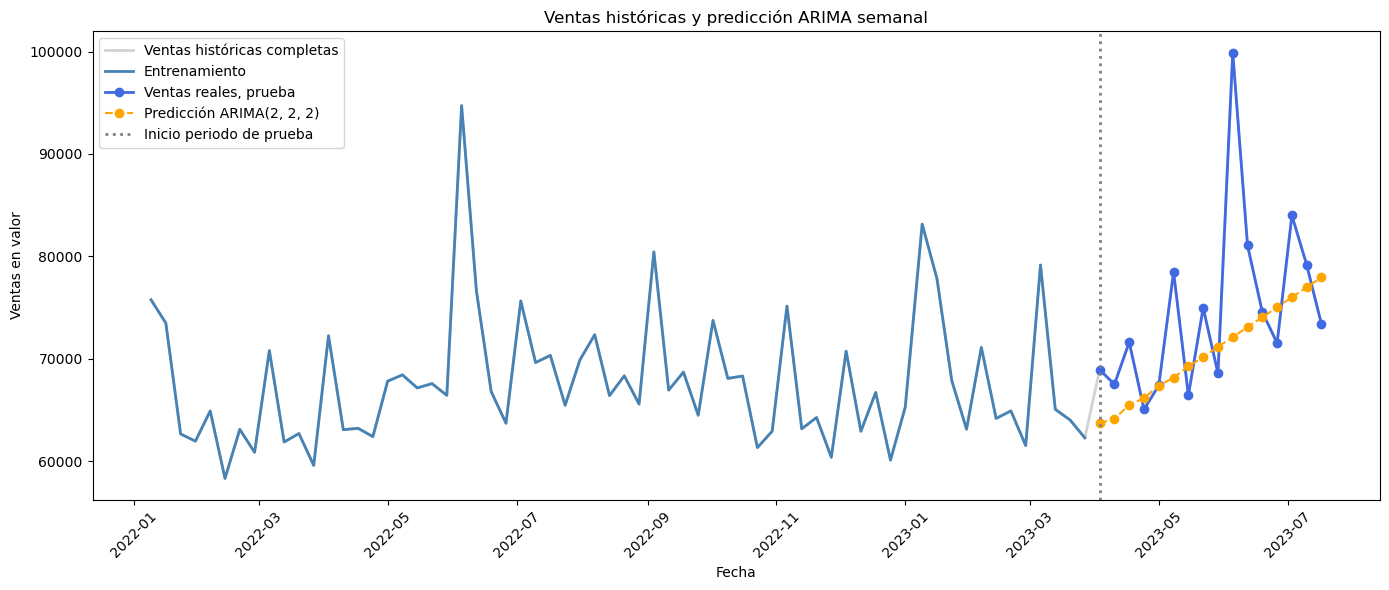

In [71]:
plt.figure(figsize=(14, 6))
plt.plot(serie_arima.index,serie_arima.values,color="lightgray",linewidth=2,label="Ventas históricas completas")
plt.plot(train_arima.index,train_arima.values,color="steelblue",linewidth=2,label="Entrenamiento")
plt.plot(test_arima.index,test_arima.values,marker="o",color="royalblue",linewidth=2,label="Ventas reales, prueba")
plt.plot(resultados_arima["DATE"],resultados_arima["prediccion_arima"],marker="o",linestyle="--",color="orange",label=f"Predicción ARIMA{mejor_order}")
plt.axvline(x=test_arima.index.min(),color="gray",linestyle=":",linewidth=2,label="Inicio periodo de prueba")
plt.title("Ventas históricas y predicción ARIMA semanal")
plt.xlabel("Fecha")
plt.ylabel("Ventas en valor")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusiones y Recomendaciones

## Resumen de los hallazgos clave

##### A lo largo del proyecto se realizó la integración, limpieza y análisis de las tablas de ventas, calendario, productos, categorías y segmentos. Durante este proceso se identificó que la región `TOTAL AUTOS SCANNING MEXICO` funcionaba como un total nacional agregado, por lo que fue separada del análisis regional para evitar duplicar las ventas. A partir de esto, el análisis se enfocó en las áreas reales de venta.

##### El conjunto analizado corresponde a la categoría general de productos de tratamiento y sanitización de telas. En total, se analizaron 350 productos, con un valor acumulado de ventas de 5,521,430.57 y 195.88K unidades vendidas. En el análisis regional se observaron diferencias relevantes entre áreas, lo que permite identificar regiones con mayor participación y otras con oportunidades de mejora.

##### El análisis por productos mostró que una parte importante de las ventas se concentra en ciertos artículos clave. Además, mediante K-Means se identificaron 4 clusters de productos: productos de volumen acumulado, productos líder, productos de presencia específica y productos de baja contribución. Esta segmentación permitió distinguir entre productos que generan ventas por amplitud de catálogo y productos que, aunque son pocos, tienen un alto impacto comercial.

##### Finalmente, se desarrolló un modelo ARIMA para la predicción semanal de ventas. Antes de aplicarlo, se realizó la prueba Dickey-Fuller para evaluar la estacionariedad de la serie. La serie original no fue estacionaria y la primera diferenciación no fue suficiente, por lo que se utilizó una segunda diferenciación. El mejor modelo probado fue ARIMA(2,2,2), con un MAE aproximado de 5,682.60 y un RMSE de 8,510.51. El modelo logró capturar la tendencia general, aunque mostró limitaciones para anticipar picos o caídas abruptas en las ventas.

## Impacto del análisis en la estrategia empresaria

##### Los resultados obtenidos pueden apoyar la toma de decisiones comerciales al ofrecer una visión más clara del comportamiento de ventas por región, producto, segmento y cluster. La separación de `SCANNING MEXICO` permitió trabajar con una base más confiable para el análisis territorial, evitando conclusiones infladas por datos duplicados.

##### La identificación de productos líder y productos de volumen acumulado ayuda a priorizar artículos estratégicos dentro del portafolio. Por un lado, los productos líder muestran alto impacto comercial con pocos artículos; por otro, los productos de volumen acumulado representan una parte importante del total debido a la amplitud del catálogo. Esta distinción puede ser útil para decisiones relacionadas con inventario, distribución, promociones y seguimiento comercial.

##### El dashboard en Power BI complementa el análisis al permitir una exploración interactiva de los datos mediante filtros por año, región, formato, segmento, marca y fabricante. Esto facilita que la empresa pueda monitorear el desempeño de ventas desde diferentes perspectivas y detectar oportunidades de mejora de manera más rápida.

## Recomendaciones

##### Se recomienda mantener separado el análisis regional del total nacional agregado, utilizando `TOTAL AUTOS SCANNING MEXICO` únicamente como referencia general y no como una región adicional. Esto evita duplicaciones y permite que los indicadores regionales sean más precisos.

##### También se recomienda dar seguimiento especial a los productos líder, ya que aunque representan pocos artículos, concentran una participación relevante del valor total de ventas. Estos productos pueden considerarse prioritarios para estrategias de inventario, disponibilidad y promoción.

##### Para los productos de volumen acumulado, se sugiere realizar un análisis más detallado para identificar cuáles artículos dentro del grupo realmente impulsan las ventas y cuáles podrían tener una contribución menor dentro del portafolio. En el caso de los productos de baja contribución, sería conveniente revisar si su desempeño se debe a poca presencia regional, baja rotación, falta de promoción o menor demanda del mercado.

##### En cuanto al modelo predictivo, se recomienda utilizarlo como una herramienta de apoyo para observar tendencias generales, no como una predicción exacta. Debido a que el modelo ARIMA no incluye variables externas, puede tener dificultades para anticipar cambios bruscos en las ventas. Por ello, sus resultados deben interpretarse como una referencia inicial.

## Futuras mejoras

##### Como mejora futura, sería recomendable incorporar más periodos históricos para fortalecer el modelo de predicción y mejorar su estabilidad. También se podrían agregar variables externas como promociones, descuentos, campañas comerciales, temporada, disponibilidad de inventario o comportamiento por región, ya que estos factores pueden influir directamente en las ventas.

##### Otra mejora sería probar modelos más avanzados de predicción, como SARIMA, Random Forest, XGBoost o modelos híbridos que combinen variables temporales con características comerciales de los productos. Esto permitiría comparar el desempeño de distintos enfoques y seleccionar el modelo más adecuado.

##### Finalmente, el dashboard en Power BI podría ampliarse con páginas adicionales enfocadas en rentabilidad, análisis por marca, desempeño por fabricante y seguimiento de productos estratégicos. Esto convertiría el reporte en una herramienta más completa para apoyar decisiones comerciales y detectar oportunidades de crecimiento.
